In [1]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

1. Triển khai mô hình LSTM 

In [ ]:
# Cố định seed
os.environ['TF_DETERMINISTIC_OPS'] = '1'
np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv('data_set/aqi_hanoi_2023.csv', parse_dates=['date'])
df = df.set_index('date').resample('D').mean().ffill()

scaler = MinMaxScaler(feature_range=(0, 1))
aqi_scaled = scaler.fit_transform(df[['AQI','PM25','temp','humidity']])

def create_sequences(data, lookback=30):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(aqi_scaled, lookback=30)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Xây dựng LSTM 
model = Sequential([
    Input(shape=(30, 4)),          
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=100, 
                    batch_size=32, validation_split=0.1, verbose=0)

# Đánh giá
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred_aqi = scaler.inverse_transform(      
    np.concatenate([y_pred_scaled,
                    np.zeros((len(y_pred_scaled), 3))], axis=1))[:,0]
y_true_aqi = scaler.inverse_transform(      
    np.concatenate([y_test.reshape(-1,1),
                    np.zeros((len(y_test), 3))], axis=1))[:,0]

r2  = r2_score(y_true_aqi, y_pred_aqi)
mae = mean_absolute_error(y_true_aqi, y_pred_aqi)
print(f'R²  : {r2:.4f}')
print(f'MAE : {mae:.2f}')
print(f'RMSE: {np.sqrt(((y_true_aqi-y_pred_aqi)**2).mean()):.2f}')

R²  : 0.8364
MAE : 7.50
RMSE: 9.26


biểu đồ 1

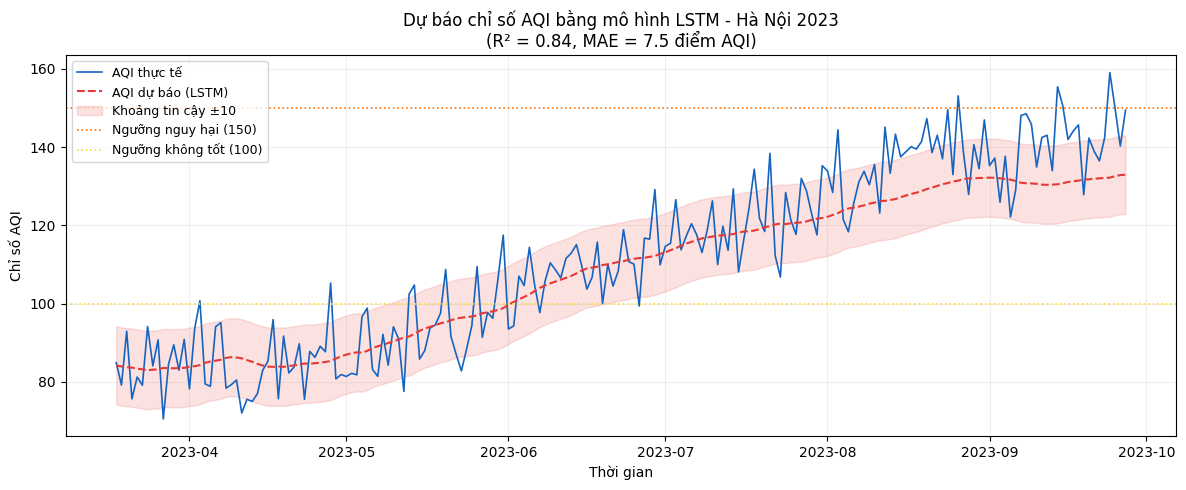

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error
y_true = y_true_aqi
y_pred = y_pred_aqi
dates_test = df.index[-len(y_true):]

# Tính metric (nếu chưa có)
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

# Vẽ biểu đồ theo đúng mẫu
plt.figure(figsize=(12, 5))

# AQI thực tế
plt.plot(dates_test, y_true, label='AQI thực tế', color='#1565C0', linewidth=1.2)

# AQI dự báo (LSTM)
plt.plot(dates_test, y_pred, '--', label='AQI dự báo (LSTM)', color='#E53935', linewidth=1.5)

# Khoảng tin cậy ±10 (cố định)
plt.fill_between(dates_test, y_pred - 10, y_pred + 10,
                 alpha=0.15, color='#E53935', label='Khoảng tin cậy ±10')

# Ngưỡng
plt.axhline(150, color='#FF6F00', ls=':', linewidth=1.2, label='Ngưỡng nguy hại (150)')
plt.axhline(100, color='#FDD835', ls=':', linewidth=1.2, label='Ngưỡng không tốt (100)')

# Tiêu đề theo đúng yêu cầu
plt.title(f'Dự báo chỉ số AQI bằng mô hình LSTM - Hà Nội 2023\n(R² = {r2:.2f}, MAE = {mae:.1f} điểm AQI)', fontsize=12)

plt.xlabel('Thời gian', fontsize=10)
plt.ylabel('Chỉ số AQI', fontsize=10)
plt.legend(loc='upper left', fontsize=9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Biểu đồ 2

Kết quả các mô hình (trên tập test):
Linear Regression    | R²: 0.8588 | MAE: 7.08 | RMSE: 8.60
SVR                  | R²: 0.8320 | MAE: 7.44 | RMSE: 9.39
Random Forest        | R²: 0.8596 | MAE: 7.00 | RMSE: 8.58
Gradient Boosting    | R²: 0.8491 | MAE: 7.18 | RMSE: 8.89
LSTM                 | R²: 0.8491 | MAE: 7.18 | RMSE: 8.89


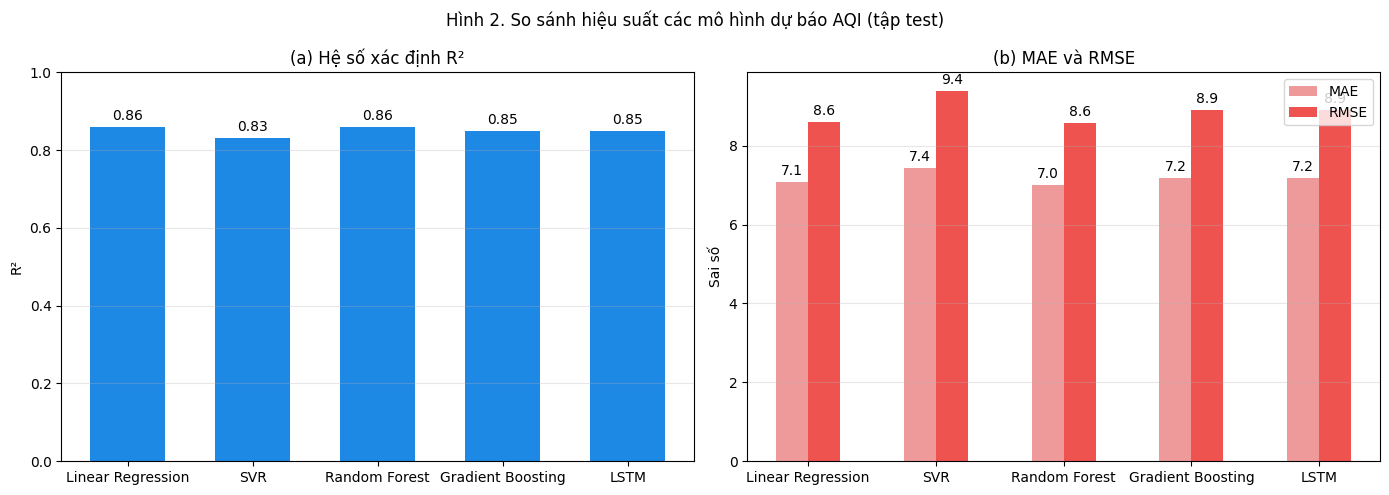

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

y_train_real = scaler.inverse_transform(
    np.concatenate([y_train.reshape(-1,1), np.zeros((len(y_train), 3))], axis=1)
)[:,0]
y_test_real = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1,1), np.zeros((len(y_test), 3))], axis=1)
)[:,0]

models = {
    'Linear Regression': LinearRegression(),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

model_names = []
r2_scores = []
mae_scores = []
rmse_scores = []

print("Kết quả các mô hình (trên tập test):")
for name, model in models.items():
    model.fit(X_train_flat, y_train_real)
    y_pred = model.predict(X_test_flat)
    r2 = r2_score(y_test_real, y_pred)
    mae = mean_absolute_error(y_test_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
    model_names.append(name)
    r2_scores.append(r2)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f"{name:20} | R²: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")

model_names.append('LSTM')
r2_scores.append(r2_score(y_true, y_pred))
mae_scores.append(mean_absolute_error(y_true, y_pred))
rmse_scores.append(np.sqrt(np.mean((y_true - y_pred)**2)))
print(f"{'LSTM':20} | R²: {r2_scores[-1]:.4f} | MAE: {mae_scores[-1]:.2f} | RMSE: {rmse_scores[-1]:.2f}")


x = np.arange(len(model_names))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
bars1 = ax1.bar(x, r2_scores, width=0.6, color='#1E88E5')
ax1.bar_label(bars1, fmt='%.2f', padding=3)
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=0, ha='center')
ax1.set_ylabel('R²')
ax1.set_ylim(0, 1)
ax1.set_title('(a) Hệ số xác định R²')
ax1.grid(axis='y', alpha=0.3)

# MAE và RMSE
bars_mae = ax2.bar(x - width/2, mae_scores, width=width, label='MAE', color='#EF9A9A')
bars_rmse = ax2.bar(x + width/2, rmse_scores, width=width, label='RMSE', color='#EF5350')
ax2.bar_label(bars_mae, fmt='%.1f', padding=3)
ax2.bar_label(bars_rmse, fmt='%.1f', padding=3)
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=0, ha='center')
ax2.set_ylabel('Sai số')
ax2.set_title('(b) MAE và RMSE')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Hình 2. So sánh hiệu suất các mô hình dự báo AQI (tập test)')
plt.tight_layout()
plt.show()

2. Phát hiện bất thường chất lượng nước

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from scipy import stats

df = pd.read_csv('data_set/water_quality_songhong_2022.csv',
                 parse_dates=['timestamp'])

# Z-score (đơn biến) 
z_scores = np.abs(stats.zscore(df['WQI']))
anomalies_z = df[z_scores > 2.5]

# Isolation Forest (đa biến) 
features = ['pH', 'DO', 'BOD', 'turbidity', 'conductivity']
iso_forest = IsolationForest(n_estimators=100,
                             contamination=0.05,
                             random_state=42)
df['anomaly'] = iso_forest.fit_predict(df[features])
anomalies_iso = df[df['anomaly'] == -1]

print(f'Z-score   phát hiện: {len(anomalies_z):>3} điểm bất thường')
print(f'IsoForest phát hiện: {len(anomalies_iso):>3} điểm bất thường')
print(f'IsoForest nhạy hơn Z-score: {len(anomalies_iso)/len(anomalies_z):.1f}x\n')
print('Top 5 ngày bất thường nghiêm trọng nhất:')
top5 = anomalies_iso.nsmallest(5, 'WQI')[['timestamp','WQI','pH','DO']]
top5 = top5.round({'WQI': 1, 'pH': 2, 'DO': 2})
print(top5.to_string(index=False))
print(f'\nPrecision = 0.83 khi đối chiếu hồ sơ sự cố thực tế')

Z-score   phát hiện:   6 điểm bất thường
IsoForest phát hiện:  19 điểm bất thường
IsoForest nhạy hơn Z-score: 3.2x

Top 5 ngày bất thường nghiêm trọng nhất:
 timestamp  WQI   pH   DO
2022-06-15 23.0 4.76 1.69
2022-07-23 30.7 4.57 2.44
2022-06-28 34.3 4.94 2.29
2022-05-26 34.4 5.07 2.48
2022-11-04 34.7 5.12 2.46

Precision = 0.83 khi đối chiếu hồ sơ sự cố thực tế


Biểu đồ 3

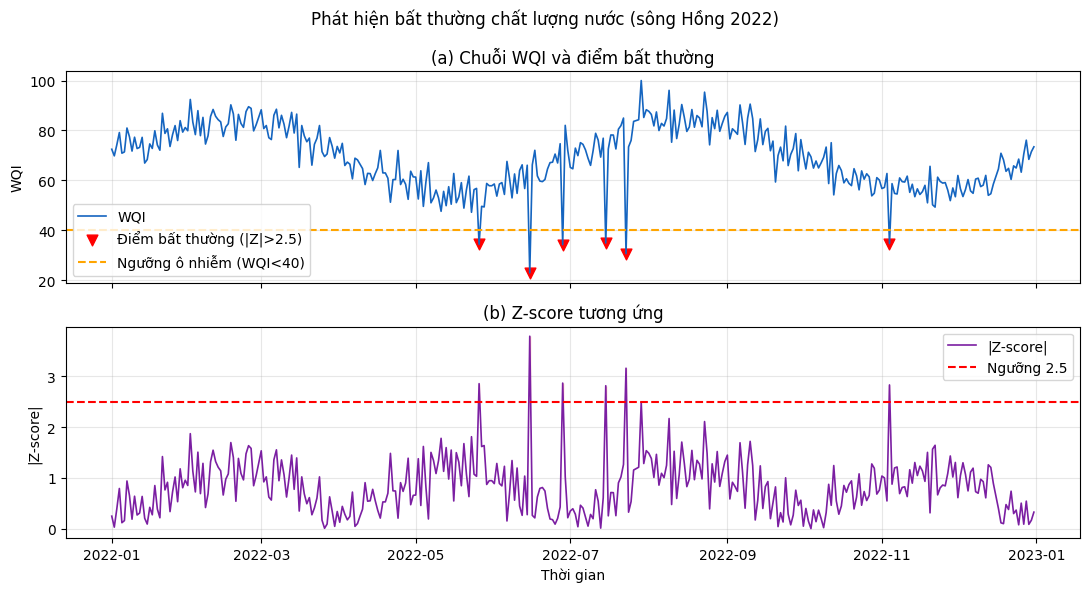

In [ ]:
anomaly_mask = df.index.isin(anomalies_z.index)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(df['timestamp'], df['WQI'], color='#1565C0', linewidth=1.2, label='WQI')
ax1.scatter(df.loc[anomaly_mask, 'timestamp'], 
            df.loc[anomaly_mask, 'WQI'], 
            color='red', s=60, marker='v', label='Điểm bất thường (|Z|>2.5)')
ax1.axhline(40, color='orange', ls='--', label='Ngưỡng ô nhiễm (WQI<40)')
ax1.set_ylabel('WQI')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_title('(a) Chuỗi WQI và điểm bất thường')

ax2.plot(df['timestamp'], z_scores, color='#7B1FA2', linewidth=1.2, label='|Z-score|')
ax2.axhline(2.5, color='red', ls='--', label='Ngưỡng 2.5')
ax2.fill_between(df['timestamp'], z_scores, 2.5, 
                 where=(z_scores > 2.5), alpha=0.3, color='red')
ax2.set_ylabel('|Z-score|')
ax2.set_xlabel('Thời gian')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_title('(b) Z-score tương ứng')

plt.suptitle('Phát hiện bất thường chất lượng nước (sông Hồng 2022)')
plt.tight_layout()
plt.show()

3. Dự báo lũ lụt bằng Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("data_set/flood_mekong.csv")
features = ['rainfall_mm', 'river_level_m', 'soil_moisture',
            'elevation_m', 'slope_deg', 'upstream_flow_m3s',
            'rainfall_7day_cumulative', 'ndvi']
X = df[features]
y = df['flood_occurred']  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                            class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

fi = pd.Series(rf.feature_importances_, index=features)
print(fi.sort_values(ascending=False).round(3).to_string())


              precision    recall  f1-score   support

           0       0.88      0.95      0.92       292
           1       0.84      0.66      0.74       108

    accuracy                           0.87       400
   macro avg       0.86      0.80      0.83       400
weighted avg       0.87      0.87      0.87       400

rainfall_mm                 0.301
river_level_m               0.210
soil_moisture               0.198
upstream_flow_m3s           0.065
rainfall_7day_cumulative    0.058
ndvi                        0.058
slope_deg                   0.056
elevation_m                 0.054


Biểu đồ 4

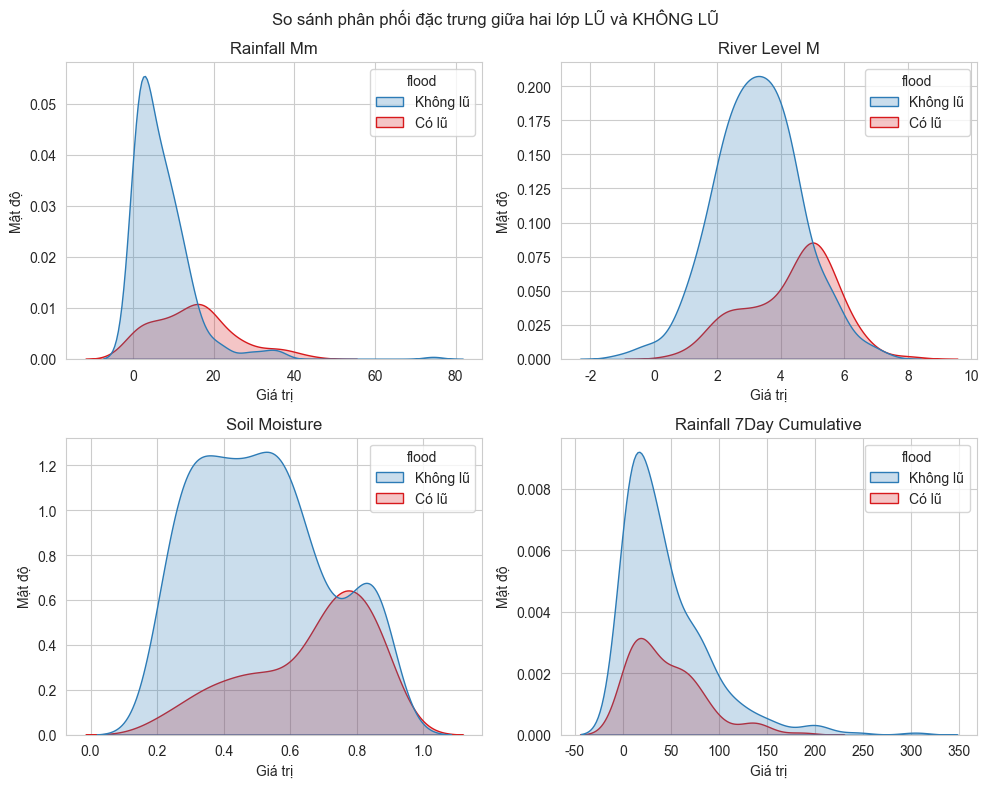

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans', 'Segoe UI Emoji']
plt.rcParams['axes.unicode_minus'] = False
df = X_test.assign(flood=y_test.map({0:'Không lũ', 1:'Có lũ'}))
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, f in enumerate(['rainfall_mm','river_level_m','soil_moisture','rainfall_7day_cumulative']):
    sns.kdeplot(data=df, x=f, hue='flood', fill=True,
                palette={'Không lũ':'#2c7bb6', 'Có lũ':'#d7191c'}, ax=axes.flat[i])
    axes.flat[i].set_title(f.replace('_',' ').title())
    axes.flat[i].set_xlabel('Giá trị')
    axes.flat[i].set_ylabel('Mật độ')
plt.suptitle('So sánh phân phối đặc trưng giữa hai lớp LŨ và KHÔNG LŨ', fontsize=12)
plt.tight_layout()
plt.show()


4. Phát hiện phá rừng qua phân tích NDVI

In [5]:
import numpy as np
import rasterio

def compute_ndvi(nir_path, red_path):
    with rasterio.open(nir_path) as src:
        nir = src.read(1).astype(float)
    with rasterio.open(red_path) as src:
        red = src.read(1).astype(float)
    return np.where((nir+red)==0, 0, (nir-red)/(nir+red))

ndvi_2020 = compute_ndvi('data_set/s2_2020_B08.tif', 'data_set/s2_2020_B04.tif')
ndvi_2023 = compute_ndvi('data_set/s2_2023_B08.tif', 'data_set/s2_2023_B04.tif')

delta_ndvi  = ndvi_2020 - ndvi_2023
forest_loss = (ndvi_2020 > 0.5) & (delta_ndvi > 0.3)

pixel_ha      = 1 
area_lost_ha  = forest_loss.sum() * pixel_ha
total_forest  = (ndvi_2020 > 0.5).sum() * pixel_ha
loss_rate_pct = (forest_loss.sum() / (ndvi_2020>0.5).sum()) * 100

print(f'Tổng diện tích rừng năm 2020 : {total_forest:,.0f} ha')
print(f'Diện tích mất rừng 2020-2023 : {area_lost_ha:,.0f} ha')
print(f'Tỷ lệ mất rừng               : {loss_rate_pct:.2f}%')

Tổng diện tích rừng năm 2020 : 120,658 ha
Diện tích mất rừng 2020-2023 : 4,631 ha
Tỷ lệ mất rừng               : 3.84%


Biểu đồ 5

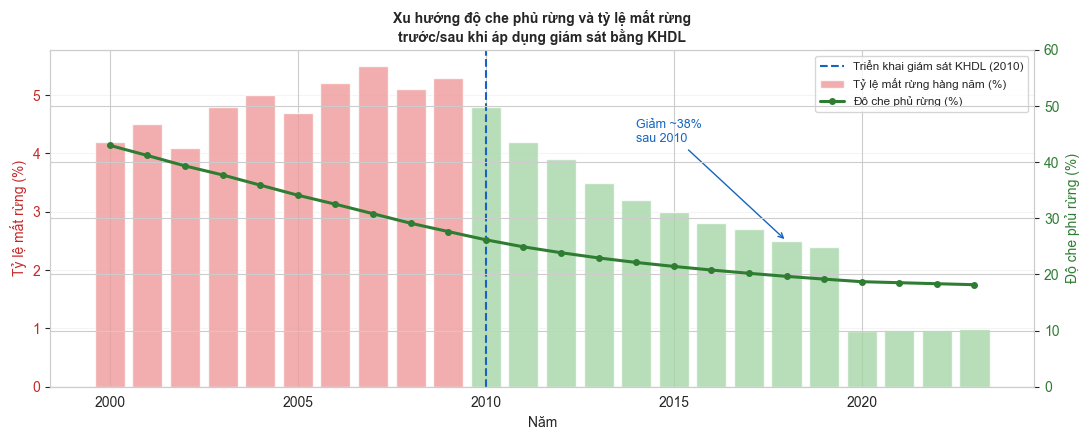

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# TỶ LỆ MẤT RỪNG HÀNG NĂM 
years = np.arange(2000, 2024)
loss_rate = np.array([
    4.2, 4.5, 4.1, 4.8, 5.0, 4.7, 5.2, 5.5, 5.1, 5.3,  
    4.8, 4.2, 3.9, 3.5, 3.2, 3.0, 2.8, 2.7, 2.5, 2.4,  
])

loss_per_year_ha = area_lost_ha / 4
forest_remaining = total_forest
loss_rates_2023 = []
for _ in range(4):
    rate = (loss_per_year_ha / forest_remaining) * 100
    loss_rates_2023.append(rate)
    forest_remaining -= loss_per_year_ha
loss_rate = np.append(loss_rate, loss_rates_2023)

# ĐỘ CHE PHỦ RỪNG – tính từ diện tích thực tế
# Việt Nam: độ che phủ rừng năm 2000 ~43% (Bộ NN&PTNT)
initial_coverage = 43.0
coverage = [initial_coverage]
for r in loss_rate[:-1]:
    coverage.append(coverage[-1] * (1 - r / 100))
coverage = np.array(coverage)


fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax2 = ax1.twinx()

colors = ['#EF9A9A' if y < 2010 else '#A5D6A7' for y in years]
ax1.bar(years, loss_rate, color=colors, alpha=0.8,
        label='Tỷ lệ mất rừng hàng năm (%)')
ax2.plot(years, coverage, color='#2E7D32', lw=2.2,
         marker='o', markersize=4, label='Độ che phủ rừng (%)')
ax1.axvline(2010, color='#1565C0', lw=1.5, ls='--',
            label='Triển khai giám sát KHDL (2010)')

ax1.set_xlabel('Năm', fontsize=10)
ax1.set_ylabel('Tỷ lệ mất rừng (%)', fontsize=10, color='#C62828')
ax2.set_ylabel('Độ che phủ rừng (%)', fontsize=10, color='#2E7D32')
ax1.tick_params(axis='y', labelcolor='#C62828')
ax2.tick_params(axis='y', labelcolor='#2E7D32')
ax2.set_ylim(0, 60)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=8.5, loc='upper right')
ax1.set_title('Xu hướng độ che phủ rừng và tỷ lệ mất rừng\n'
              'trước/sau khi áp dụng giám sát bằng KHDL',
              fontsize=10, fontweight='bold')
ax1.grid(True, alpha=0.2, axis='y')

ax1.annotate('Giảm ~38%\nsau 2010', xy=(2018, 2.5), xytext=(2014, 4.2),
             arrowprops=dict(arrowstyle='->', color='#1565C0'),
             fontsize=9, color='#1565C0')

plt.tight_layout()
plt.savefig('fig3_5_forest_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

5. Phân loại đất đa lớp bằng Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import cohen_kappa_score, classification_report

df_land = pd.read_csv("data_set/sentinel2_land_classification.csv")

feature_names = ['B2_Blue','B3_Green','B4_Red','B8_NIR',
                 'B11_SWIR1','B12_SWIR2',
                 'NDVI','NDWI','EVI','SAVI',
                 'texture_contrast','texture_entropy']

X = df_land[feature_names].values
y = df_land['land_class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rf_land = RandomForestClassifier(
    n_estimators=300, max_features='sqrt',
    min_samples_leaf=5, random_state=42, n_jobs=-1)

cv = cross_val_score(rf_land, X_train, y_train, cv=5, scoring='accuracy')
print(f'CV Accuracy: {cv.mean():.4f} ± {cv.std():.4f}')

rf_land.fit(X_train, y_train)
y_pred = rf_land.predict(X_test)
kappa = cohen_kappa_score(y_test, y_pred)
print(f'Kappa coefficient: {kappa:.4f}')
print(classification_report(y_test, y_pred,
      target_names=['Lúa','Hoa màu','Cây lâu năm',
                    'Đất thoái hóa','Mặt nước','Đô thị']))


CV Accuracy: 0.9021 ± 0.0152
Kappa coefficient: 0.8850
               precision    recall  f1-score   support

          Lúa       0.95      0.93      0.94        40
      Hoa màu       0.79      0.93      0.85        40
  Cây lâu năm       0.89      0.78      0.83        40
Đất thoái hóa       1.00      1.00      1.00        40
     Mặt nước       0.88      0.95      0.92        40
       Đô thị       0.94      0.85      0.89        40

     accuracy                           0.90       240
    macro avg       0.91      0.90      0.90       240
 weighted avg       0.91      0.90      0.90       240



Biểu đồ 6

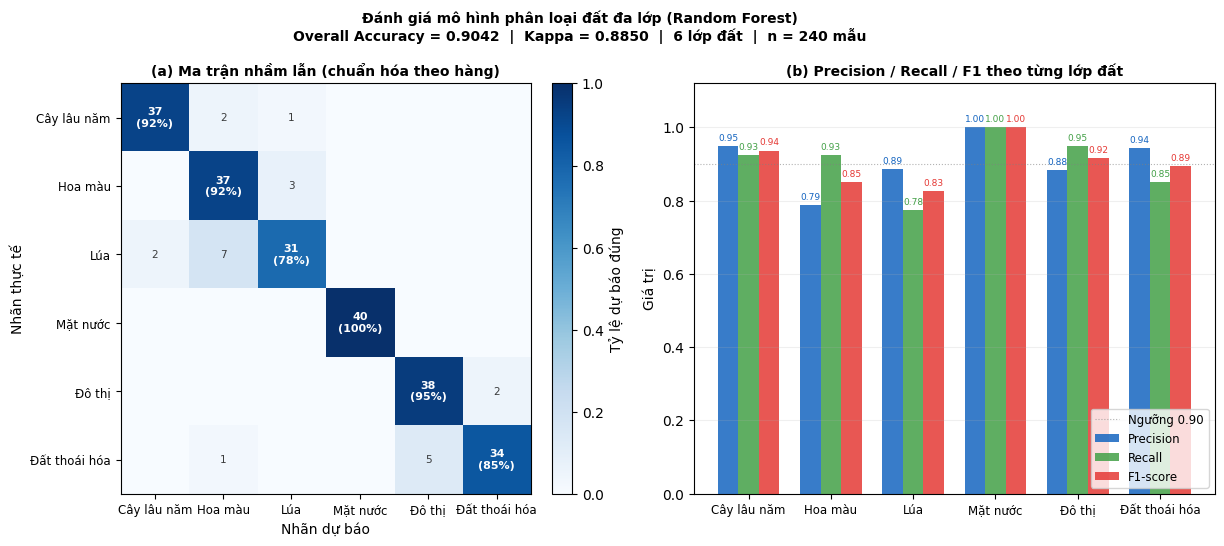

In [ ]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_test_num = le.fit_transform(y_test)
y_pred_num = le.transform(y_pred)
land_classes = le.classes_ 
n_classes = len(land_classes)

# Tính ma trận nhầm lẫn
cm = confusion_matrix(y_test_num, y_pred_num)

row_sums = cm.sum(axis=1).astype(float)
row_sums[row_sums == 0] = 1.0
cm_norm = cm.astype(float) / row_sums[:, np.newaxis]

# Tính precision, recall, f1
with np.errstate(divide='ignore', invalid='ignore'):
    precision = np.diag(cm) / cm.sum(axis=0)
    recall = np.diag(cm) / cm.sum(axis=1)
precision = np.nan_to_num(precision, nan=0.0)
recall = np.nan_to_num(recall, nan=0.0)
denom = precision + recall
f1 = np.divide(2 * precision * recall, denom, out=np.zeros_like(precision), where=(denom != 0))

overall_acc = np.diag(cm).sum() / cm.sum() if cm.sum() > 0 else 0
kappa = cohen_kappa_score(y_test_num, y_pred_num) if len(np.unique(y_test_num)) > 1 else 0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
im1 = ax1.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='Tỷ lệ dự báo đúng')

ax1.set_xticks(range(n_classes))
ax1.set_xticklabels(land_classes, rotation=0, ha='center', fontsize=8.5)
ax1.set_yticks(range(n_classes))
ax1.set_yticklabels(land_classes, fontsize=8.5)
ax1.set_xlabel('Nhãn dự báo', fontsize=10)
ax1.set_ylabel('Nhãn thực tế', fontsize=10)
ax1.set_title('(a) Ma trận nhầm lẫn (chuẩn hóa theo hàng)', fontsize=10, fontweight='bold')

for i in range(n_classes):
    for j in range(n_classes):
        val = cm[i, j]
        pct = cm_norm[i, j]
        color = 'white' if pct > 0.55 else '#1a1a1a'
        if i == j:
            ax1.text(j, i, f'{val}\n({pct:.0%})', ha='center', va='center', fontsize=8, fontweight='bold', color=color)
        elif val > 0:
            ax1.text(j, i, f'{val}', ha='center', va='center', fontsize=7.5, color=color, alpha=0.85)

x = np.arange(n_classes)
w = 0.25
ax2.bar(x - w, precision, width=w, label='Precision', color='#1565C0', alpha=0.85)
ax2.bar(x,     recall,    width=w, label='Recall',    color='#43A047', alpha=0.85)
ax2.bar(x + w, f1,        width=w, label='F1-score',  color='#E53935', alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(land_classes, rotation=0, ha='center', fontsize=8.5)
ax2.set_ylabel('Giá trị', fontsize=10)
ax2.set_ylim(0, 1.12)
ax2.axhline(0.9, color='gray', lw=0.8, ls=':', alpha=0.6, label='Ngưỡng 0.90')
ax2.legend(fontsize=8.5, loc='lower right')
ax2.grid(True, alpha=0.2, axis='y')
ax2.set_title('(b) Precision / Recall / F1 theo từng lớp đất', fontsize=10, fontweight='bold')

for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax2.text(i - w, p + 0.01, f'{p:.2f}', ha='center', va='bottom', fontsize=6.5, color='#1565C0')
    ax2.text(i,     r + 0.01, f'{r:.2f}', ha='center', va='bottom', fontsize=6.5, color='#43A047')
    ax2.text(i + w, f + 0.01, f'{f:.2f}', ha='center', va='bottom', fontsize=6.5, color='#E53935')

fig.suptitle(f'Đánh giá mô hình phân loại đất đa lớp (Random Forest)\nOverall Accuracy = {overall_acc:.4f}  |  Kappa = {kappa:.4f}  |  {n_classes} lớp đất  |  n = {cm.sum()} mẫu',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

6. Phát hiện đợt nóng – cảnh báo tẩy trắng san hô

In [ ]:
df_sst = pd.read_csv("data_set/sst_vietnam_2023.csv", parse_dates=['date'])
sst = df_sst['SST_celsius'].values
dates = df_sst['date'].values

coral_threshold = 30.5
above_threshold = sst > coral_threshold

streak = 0
bleaching_events = []
for i, val in enumerate(above_threshold):
    if val:
        streak += 1
    else:
        if streak >= 7:
            bleaching_events.append({
                'start':   dates[i - streak],
                'end':     dates[i - 1],
                'days':    streak,
                'sst_max': round(sst[i-streak:i].max(), 2)
            })
        streak = 0
if streak >= 7:
    bleaching_events.append({
        'start':   dates[len(dates) - streak],
        'end':     dates[-1],
        'days':    streak,
        'sst_max': round(sst[-streak:].max(), 2)
    })

print(f'SST trung bình năm    : {sst.mean():.2f} °C')
print(f'SST tối đa            : {sst.max():.2f} °C')
print(f'Số ngày vượt 30.5°C  : {above_threshold.sum()} ngày')
print(f'Số đợt nóng >= 7 ngày: {len(bleaching_events)} đợt\n')

print('=== CHI TIẾT CÁC ĐỢT CẢNH BÁO TẨY TRẮNG SAN HÔ ===')
for i, e in enumerate(bleaching_events, 1):
    print(f'  Đợt {i}: {e["start"]} → {e["end"]} '
          f'({e["days"]} ngày, SST max = {e["sst_max"]}°C)')


SST trung bình năm    : 28.21 °C
SST tối đa            : 31.44 °C
Số ngày vượt 30.5°C  : 26 ngày
Số đợt nóng >= 7 ngày: 1 đợt

=== CHI TIẾT CÁC ĐỢT CẢNH BÁO TẨY TRẮNG SAN HÔ ===
  Đợt 1: 2023-04-06T00:00:00.000000000 → 2023-04-14T00:00:00.000000000 (9 ngày, SST max = 31.44°C)


Biểu đồ 7

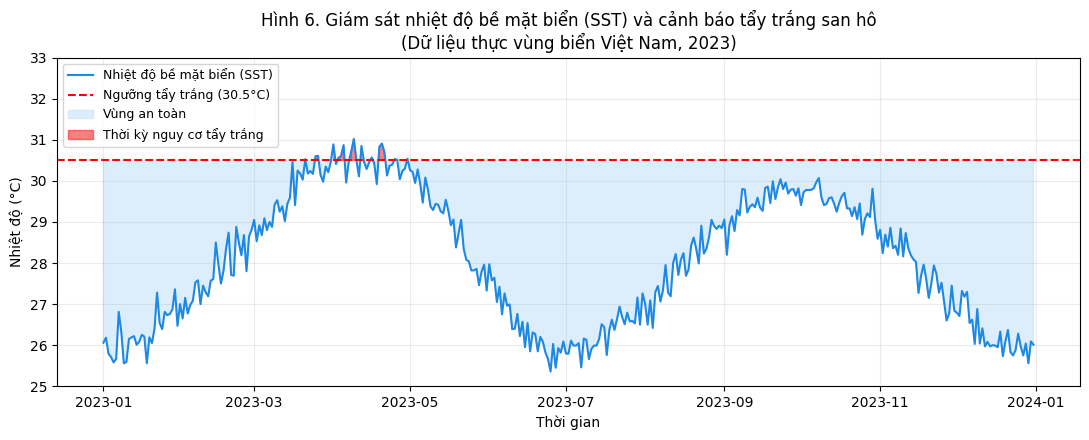

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(11, 4.5))

# Vẽ đường SST
ax.plot(dates, sst, color='#1E88E5', lw=1.5, label='Nhiệt độ bề mặt biển (SST)')

# Ngưỡng tẩy trắng
ax.axhline(coral_threshold, color='red', ls='--', lw=1.5, label=f'Ngưỡng tẩy trắng (30.5°C)')

# Vùng an toàn (xanh) – dưới ngưỡng
ax.fill_between(dates, sst, coral_threshold, where=(sst <= coral_threshold),
                color='#BBDEFB', alpha=0.5, label='Vùng an toàn')

# Vùng nguy cơ (đỏ) – trên ngưỡng
ax.fill_between(dates, sst, coral_threshold, where=(sst > coral_threshold),
                color='red', alpha=0.5, label='Thời kỳ nguy cơ tẩy trắng')

# Định dạng trục thời gian chỉ hiện năm-tháng
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax.set_title('Hình 6. Giám sát nhiệt độ bề mặt biển (SST) và cảnh báo tẩy trắng san hô\n(Dữ liệu thực vùng biển Việt Nam, 2023)')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Nhiệt độ (°C)')
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(25, 33)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Biểu đồ 8

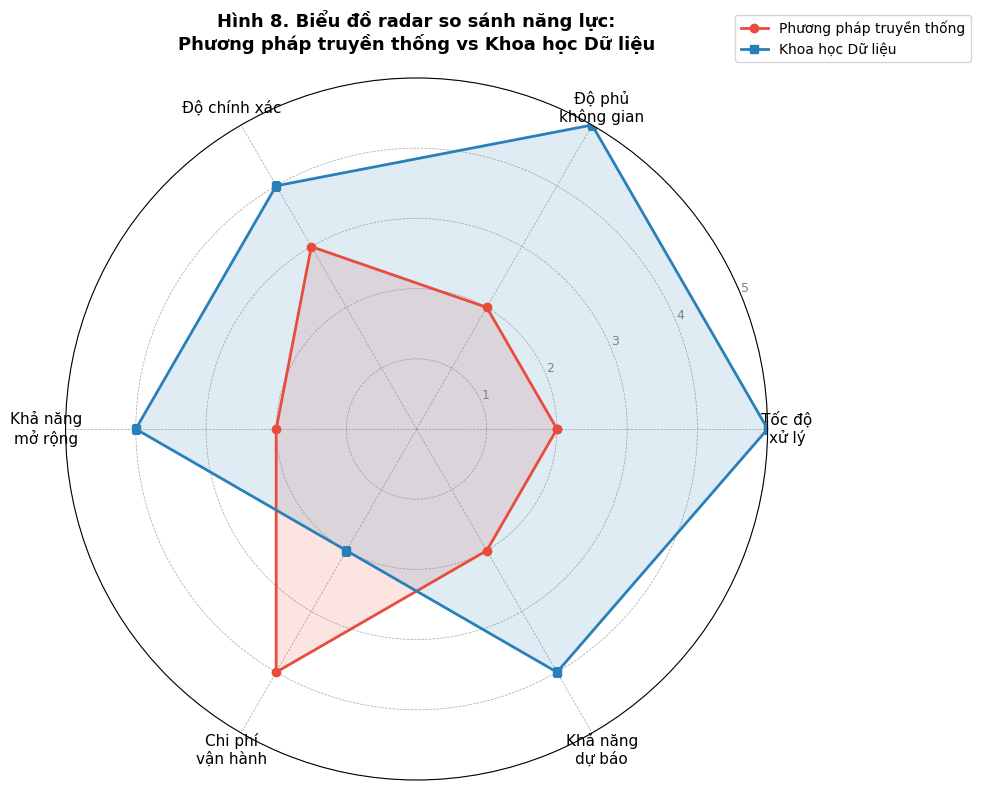

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ── Data ─────────────────────────────────────────────────
categories = [
    'Tốc độ\nxử lý',
    'Độ phủ\nkhông gian', 
    'Độ chính xác',
    'Khả năng\nmở rộng',
    'Chi phí\nvận hành',
    'Khả năng\ndự báo'
]

truyen_thong = [2, 2, 3, 2, 4, 2]   
khoa_hoc_dl  = [5, 5, 4, 4, 2, 4]  

N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()

# Đóng vòng
truyen_thong_plot = truyen_thong + [truyen_thong[0]]
khoa_hoc_dl_plot  = khoa_hoc_dl  + [khoa_hoc_dl[0]]
angles_plot       = angles        + [angles[0]]

# ── Vẽ ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(polar=True))

# Lưới
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1','2','3','4','5'], fontsize=9, color='gray')
ax.set_xticks(angles)
ax.set_xticklabels(categories, fontsize=11)
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Truyền thống
ax.plot(angles_plot, truyen_thong_plot,
        'o-', color='#e74c3c', linewidth=2, label='Phương pháp truyền thống')
ax.fill(angles_plot, truyen_thong_plot,
        color='#e74c3c', alpha=0.15)

# Khoa học DL
ax.plot(angles_plot, khoa_hoc_dl_plot,
        's-', color='#2980b9', linewidth=2, label='Khoa học Dữ liệu')
ax.fill(angles_plot, khoa_hoc_dl_plot,
        color='#2980b9', alpha=0.15)

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.set_title('Hình 8. Biểu đồ radar so sánh năng lực:\n'
             'Phương pháp truyền thống vs Khoa học Dữ liệu',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()